In [1]:
%reload_ext autoreload
%autoreload 2

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

import sys
sys.path.append("..")

import numpy as np
import pickle
from jax import jit, vmap
import jax.numpy as jnp

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
from utils.cart import to_cart
from models.np_model import NPModel

In [3]:
npmodel = NPModel(
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [4]:
samples = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))
samples.keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x', 'theta_p_macias2019', 'theta_p_coleman2019', 'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019', 'theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics', 'theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib', 'zs'])

In [5]:
t_dict = {}

## visualize bulges

In [7]:
extent = 10 # [deg]
pixelsize = 0.1
npixels = int(2 * extent / pixelsize)
mask_b = 2 # [deg]

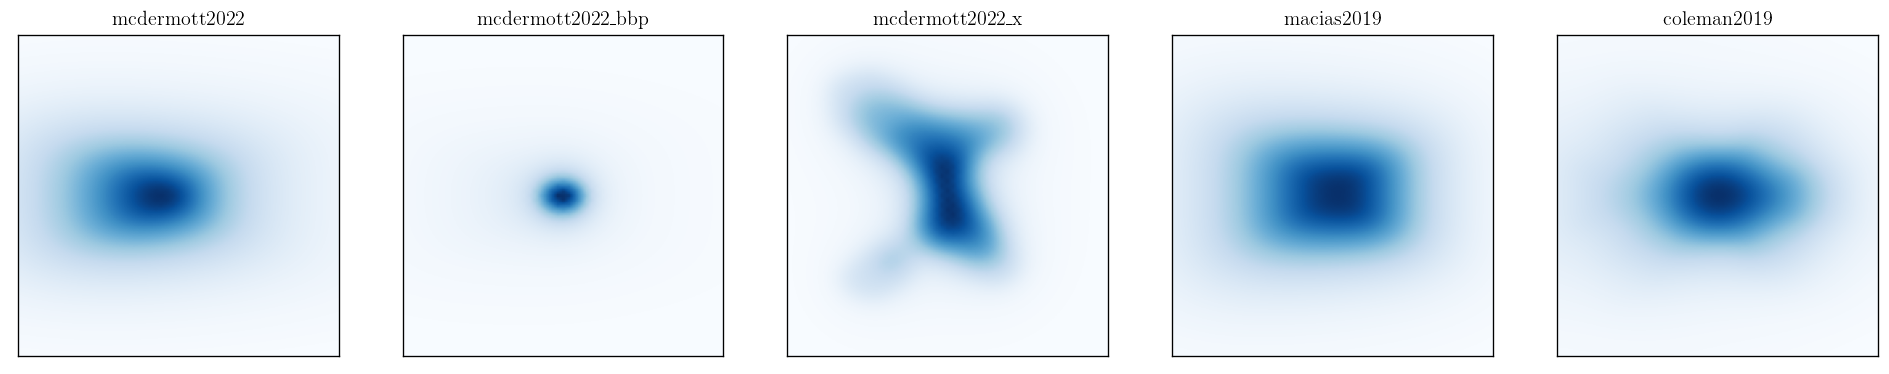

In [8]:
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axs[i].imshow(
        to_cart(np.array(npmodel.bulge_templates[i]), n_pixels=npixels, pixelsize=pixelsize),
        cmap='Blues'
    )
    axs[i].set(title=bulge_names[i], xticks=[], yticks=[])

## get templates median variance

In [6]:
t_dict = {}

In [7]:
def get_mask(extent=10, pixelsize=0.1, mask_b=2): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    mask_plane_cart = np.zeros((npixels, npixels), dtype=np.int32)
    i_mask_b_fm = int((extent - mask_b) / pixelsize)
    i_mask_b_to = int((extent + mask_b) / pixelsize)
    mask_plane_cart[i_mask_b_fm:i_mask_b_to] = 1
    return np.array(mask_plane_cart, dtype=bool)

mask = get_mask()

def get_t_med_var(ts, extent=10, pixelsize=0.1): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    t_med = jnp.median(ts, axis=0)
    t_var = jnp.quantile(ts, 0.84, axis=0) - jnp.quantile(ts, 0.16, axis=0)
    t_med_cart = to_cart(np.array(t_med), n_pixels=npixels, pixelsize=pixelsize)
    t_var_cart = to_cart(np.array(t_var), n_pixels=npixels, pixelsize=pixelsize)
    
    return t_med_cart, t_var_cart

def get_cart_from_hp(m, extent=10, pixelsize=0.1): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    return to_cart(np.array(m), n_pixels=npixels, pixelsize=pixelsize)

In [8]:
name = 'dsk'
n_plot = 1000

def get_dsk_templates(S, zs, C):
    return S * npmodel.disk_template.get_template(zs=zs, C=C)

get_dsk_templates_vmap = vmap(get_dsk_templates, in_axes=(0, 0, 0), out_axes=0)

ts = get_dsk_templates_vmap(samples['Sps_dsk'][:n_plot], samples['zs'][:n_plot], samples['C'][:n_plot])
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

In [9]:
name = 'gce_ps'
n_plot = 1000

def get_nfw_templates(S, gamma):
    return S * npmodel.nfw_template.get_NFW2_template(gamma=gamma)
def get_blg_templates(S, theta):
    return S * jnp.dot(theta, npmodel.bulge_templates)
def get_gce_templates(S_gce, f_bulge, gamma, theta):
    return get_nfw_templates(S_gce*(1-f_bulge), gamma) + get_blg_templates(S_gce*f_bulge, theta)

get_gce_templates_vmap = vmap(get_gce_templates, in_axes=(0, 0, 0, 1), out_axes=0)

ts = get_gce_templates_vmap(
    samples['Sps_gce'][:n_plot],
    samples['f_bulge_ps'][:n_plot],
    samples['gamma_ps'][:n_plot],
    jnp.array([
        samples['theta_ps_mcdermott2022'][:n_plot],
        samples['theta_ps_mcdermott2022_bbp'][:n_plot],
        samples['theta_ps_mcdermott2022_x'][:n_plot],
        samples['theta_ps_macias2019'][:n_plot],
        samples['theta_ps_coleman2019'][:n_plot],
    ])
)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

In [10]:
name = 'gce_poiss'
n_plot = 1000

ts = get_gce_templates_vmap(
    samples['S_gce'][:n_plot],
    samples['f_bulge_poiss'][:n_plot],
    samples['gamma_poiss'][:n_plot],
    jnp.array([
        samples['theta_p_mcdermott2022'][:n_plot],
        samples['theta_p_mcdermott2022_bbp'][:n_plot],
        samples['theta_p_mcdermott2022_x'][:n_plot],
        samples['theta_p_macias2019'][:n_plot],
        samples['theta_p_coleman2019'][:n_plot],
    ])
)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

In [11]:
t_dict.keys()

dict_keys(['dsk_med', 'dsk_var', 'gce_ps_med', 'gce_ps_var', 'gce_poiss_med', 'gce_poiss_var'])

## which bulge is the largest

In [18]:
for bn in bulge_names:
    print(bn, np.mean(samples['theta_ps_'+bn]))

mcdermott2022 0.10391602932729165
mcdermott2022_bbp 0.06434174834365122
mcdermott2022_x 0.0817937394324171
macias2019 0.5325512167380891
coleman2019 0.21739726615855098


In [20]:
for bn in bulge_names:
    print(bn, np.mean(samples['theta_p_'+bn]))

mcdermott2022 0.21766781051642764
mcdermott2022_bbp 0.1774336344760505
mcdermott2022_x 0.09254834744938457
macias2019 0.19772915876035346
coleman2019 0.3146210487977839


## view

In [14]:
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']

options = {
    'dsk'       : dict(plot_bulge=None, plot_nfw=False, n_level=10, title='Disk'),
    'gce_ps'    : dict(plot_bulge='macias2019', plot_nfw=True, n_level=7, title='GCE point source'),
    'gce_poiss' : dict(plot_bulge='coleman2019', plot_nfw=True, n_level=7, title='GCE diffuse'),
}

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

/n/home07/yitians/anaconda3/envs/torch/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


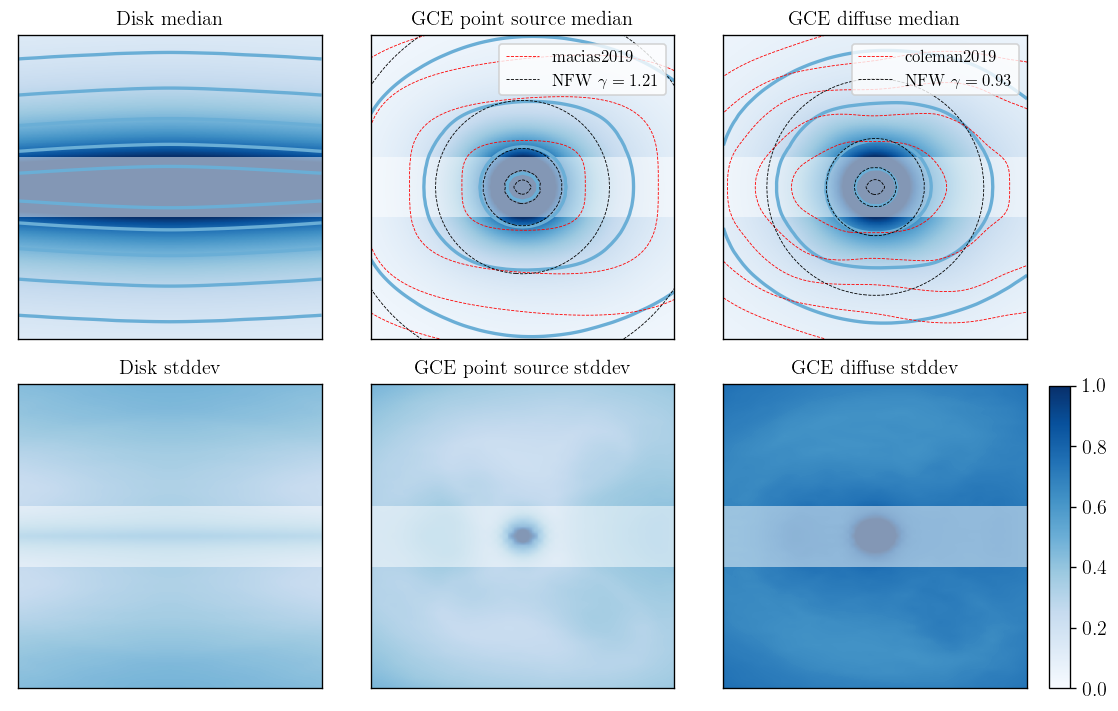

In [25]:
n_plot = len(options.items())
extent = 10
mask_b = 2
plot_extent = (-extent, extent, extent, -extent)

main_cmap = mpl.cm.get_cmap('Blues')

fig, axs = plt.subplots(2, n_plot, figsize=(3*n_plot, 6), tight_layout=True)

for i, (name, option) in enumerate(options.items()):

    t_med = np.array(t_dict[name+'_med'])
    #t_med[mask] = np.nan
    t_var = np.array(t_dict[name+'_var'])
    #t_var[mask] = np.nan
    
    vmax_masked = np.max(t_med[~mask])
    vmax = np.max(t_med)
    
    axs[0,i].imshow(np.flip(t_med), vmax=vmax_masked, vmin=0, cmap=main_cmap, extent=plot_extent)
    cs = axs[0,i].contour(np.flip(t_med), colors=mpl.colors.to_hex(main_cmap(0.5), keep_alpha=True),
                          levels=np.geomspace(0.1, vmax, option['n_level']), extent=plot_extent, linewidths=2)
    #axs[0,i].clabel(cs, inline=True, fontsize=10)
    
    have_legend = False
    if option['plot_bulge'] is not None:
        have_legend = True
        i_blg = bulge_names.index(option['plot_bulge'])
        t_blg = get_cart_from_hp(npmodel.bulge_templates[i_blg])
        vmax_masked_blg = np.max(t_blg[~mask])
        t_blg *= vmax_masked / vmax_masked_blg
        vmax_blg = np.max(t_blg)
        cs1 = axs[0,i].contour(np.flip(t_blg), colors='red', levels=np.geomspace(0.1, vmax, option['n_level']),
                         linestyles='--', extent=plot_extent, linewidths=0.5)
        h1, _ = cs1.legend_elements()
        #axs[0,i].text(0.6, 0.9, option['plot_bulge'], transform=axs[0,i].transAxes, color='red')
        #cs.collections[0].set_label(option['plot_bulge'])
    if option['plot_nfw']:
        have_legend = True
        if 'ps' in name:
            gamma_best_fit = np.mean(samples['gamma_ps'])
        else:
            gamma_best_fit = np.mean(samples['gamma_poiss'])
        t_nfw = get_cart_from_hp(npmodel.nfw_template.get_NFW2_template(gamma=gamma_best_fit))
        vmax_masked_nfw = np.max(t_nfw[~mask])
        t_nfw *= vmax_masked / vmax_masked_nfw
        vmax_nfw = np.max(t_nfw)
        cs2 = axs[0,i].contour(np.flip(t_nfw), colors='k', levels=np.geomspace(0.1, vmax, option['n_level']),
                         linestyles='--', extent=plot_extent, linewidths=0.5)
        h2, _ = cs2.legend_elements()
        #axs[0,i].text(0.6, 0.8, , transform=axs[0,i].transAxes, color='blue')
        #cs.collections[0].set_label(f'NFW $\gamma={gamma_best_fit:.3f}$')
        
    if have_legend:
        axs[0,i].legend([h1[0], h2[0]], [option['plot_bulge'], f'NFW $\gamma={gamma_best_fit:.2f}$'], fontsize=10)
    
    axs[0,i].fill_between([-extent, extent], [-mask_b, -mask_b], [+mask_b, +mask_b], color='white', alpha=0.5, ec='none')
    axs[1,i].fill_between([-extent, extent], [-mask_b, -mask_b], [+mask_b, +mask_b], color='white', alpha=0.5, ec='none')
    
    im = axs[1,i].imshow(np.flip(t_var)/np.flip(t_med), vmax=1, vmin=0, cmap=main_cmap, extent=plot_extent)
    axs[0,i].set(xticks=[], yticks=[], title=option['title']+' median')
    axs[1,i].set(xticks=[], yticks=[], title=option['title']+' stddev')
    
cax = fig.add_axes([0.99, 0.034, 0.02, 0.42])
#divider = make_axes_locatable(axs[1, 2])
#cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(axs[1, 2].images[0], cax=cax, aspect=40)